<a href="https://colab.research.google.com/github/dhakalsameer/CG-/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



KNN
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Decision Tree
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Logistic Regression
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

SVM
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Naive Bayes
Accuracy: 0.9778
Precision: 0.9762
Recall: 0.9744
F1-score: 0.9743


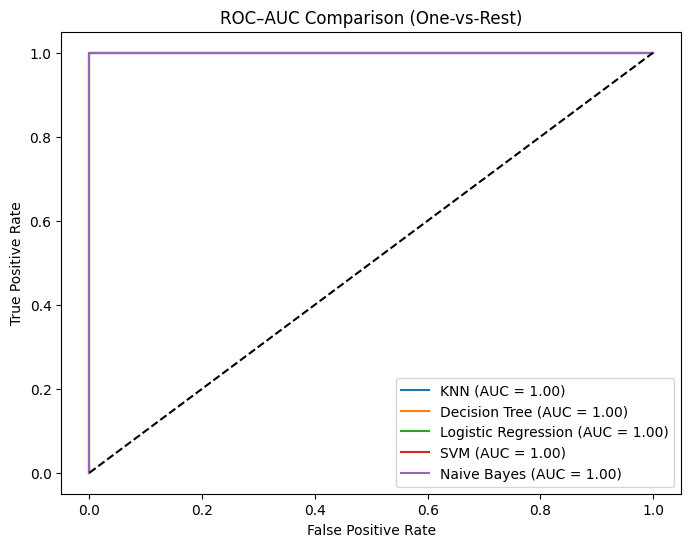

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Binarize labels for ROC (multiclass)
y_bin = label_binarize(y, classes=[0, 1, 2])
n_classes = y_bin.shape[1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Feature scaling (important for LR & SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(
        multi_class='multinomial', solver='lbfgs', max_iter=200
    ),
    "SVM": SVC(kernel='rbf', probability=True),
    "Naive Bayes": GaussianNB()
}

results = {}
roc_data = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='macro'),
        "Recall": recall_score(y_test, y_pred, average='macro'),
        "F1-score": f1_score(y_test, y_pred, average='macro')
    }

    # ROC data (macro-average)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    roc_data[name] = (fpr, tpr, roc_auc)

for model, metrics in results.items():
    print(f"\n{model}")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

plt.figure(figsize=(8, 6))

for model_name, (fpr, tpr, roc_auc) in roc_data.items():
    mean_auc = np.mean(list(roc_auc.values()))
    plt.plot(fpr[0], tpr[0], label=f"{model_name} (AUC = {mean_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Comparison (One-vs-Rest)")
plt.legend()
plt.show()


1. Why use ROC–AUC for multiclass classification?
Ans:
ROC–AUC measures class separability
OvR strategy converts multiclass into multiple binary problems
Macro-average gives equal importance to all classes


2. Which classifier performed best?
Ans:
Logistic Regression / SVM typically achieve highest ROC–AUC
They handle overlapping class boundaries effectively


3. Why do some models perform worse?
Ans:
KNN is sensitive to distance and local noise
Decision Tree may overfit
Naive Bayes assumes feature independence


4. Key Observation
Ans:
Setosa is almost perfectly classified
Versicolor & Virginica overlap, causing misclassification